### PROBABILITY ANALYSIS

This notebook analyse the probability of picking RFI in the DME band as a function of time and  
frequency on Lband MeerKAT data. The data was extracted from  the KATHPRFI (Karoo Array    
Telescope   Historical Probability of Radio Frequency Interference) framework (Sihlangu et al., 2022).  


In [1]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import re

In [2]:
# 1. Define standard journal font sizes (in points)
FONT_SIZE_BASE = 10  # Matches typical manuscript body text
FONT_SIZE_SMALL = 8  # For tick labels and legends

# 2. Update Matplotlib configuration globally
plt.rcParams.update({
    'font.size': FONT_SIZE_BASE,          # Base font size for general text
    'axes.labelsize': FONT_SIZE_BASE,     # X and Y axis labels
    'axes.titlesize': FONT_SIZE_BASE + 2, # Subplot titles
    'xtick.labelsize': FONT_SIZE_SMALL,   # X-axis tick labels
    'ytick.labelsize': FONT_SIZE_SMALL,   # Y-axis tick labels
    'legend.fontsize': FONT_SIZE_SMALL,   # Legend font size
    'figure.titlesize': FONT_SIZE_BASE + 4,# Main figure title
    
    # Optional: Font families preferred by publishers (e.g., Times New Roman or STIX)
    'font.family': 'serif',
    'mathtext.fontset': 'stix'             # Matches LaTeX document typography
})


In [3]:
def combine(path) -> xr.DataArray:
    """
    Combine multiple observation files into a single 3D xarray.DataArray
    with dimensions corresponding to observation date, time of day,
    and frequency.

    The observation date is extracted from the Unix timestamp contained
    in each filename.

    Parameters
    ----------
    path : str
        Path to the text file containing the list of observation files.

    Returns
    -------
    xarray.DataArray
        A 3D DataArray containing the RFI probability as a function of
        observation date, time, and frequency with dimensions
        (observation_date, time, frequency).
    """

    zarr_file = [
    item for item in os.listdir(path)
    if os.path.isdir(os.path.join(path, item))
    and item.endswith(".zarr")
    ]

    data_array = []

    for file in zarr_file:
        
        # 1. open file and compute 1D result
        full_path = os.path.join(path, file)
        ds = xr.open_zarr(full_path, consolidated=False)
        da = ds["probability"]
        frequency = ds["frequency"]
        
        bandwidth = float(frequency[-1] - frequency[0])*1e-6
        spacing = 0.20893335342407227
        channel = int(bandwidth / spacing)
        
        if frequency.shape[0] > channel:
            # Convert Unix Timestamp in file name to UTC
            timestamp = int(re.search(r"\d{10}", file).group())
            time_utc = pd.to_datetime(timestamp, unit="s", utc=True)

            # Add observation dimension
            da = da.expand_dims(date=[time_utc])
            data_array.append(da)
        
        else:
            print(f"File in {full_path} has a bad shape")
    observation = xr.concat(data_array, dim ="date")

    return observation

In [12]:
def probability(data) -> xr.DataArray:
    """
    This function extract the probability as a function of time from dataset
    
    Parameters
    ----------
    data : xarray.Datasets
        Contains a 3D data (date, time, frequency) 

    Returns
    -------
    probability : xarray.dataArray
        RFI weighted probability as a function time
    """


    # Define weight from observation date duraition
    weights = data.notnull().sum(dim=["time", "frequency"])
    weighted_data = data.weighted(weights)


    # Probability as a function of time
    # Weighted average
    weighted_mean_prob = weighted_data.mean(dim=["date", "frequency"])

    weighted_std_prob = weighted_data.std(dim=["date", "frequency"])

    return weighted_mean_prob, weighted_std_prob


    

In [ ]:
def plot(data, mean_prob, std, time, title):

    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(time, mean_prob, marker="o", label ='Mean')
    ax.set_xticks(np.arange(0,24,2))

    # Add the standard deviation band
    ax.fill_between(
        time, 
        mean_prob + std, 
        mean_prob - std, 
        color="blue", 
        alpha=0.2, 
        label="1 Std Dev"
    )
    ax.set_xlim(left=0, right=23)
    ax.grid(alpha=0.2)
    ax.set_xlabel("Time of Day (UTC)")
    ax.set_ylabel("Probability")
    ax.set_title(title)
    ax.legend()
    return fig

In [116]:
path = "/home/it/Documents/rfi/data/prob_time_freq_962_1213"
data = combine(path)
time = data["time"]
frequency = data["frequency"]*1e-6 # Frequency in MHz
date = data["date"]


# Define weight from observation date duraition
weights = data.notnull().sum(dim=["time", "frequency"])
weighted_data = data.weighted(weights)

# 68% confidence interval
lower = weighted_data.quantile(0.84, dim=("date","time"))
uper = weighted_data.quantile(0.16, dim=("date","time"))


Text(0.5, 1.0, 'DME band RFI Heatmap')

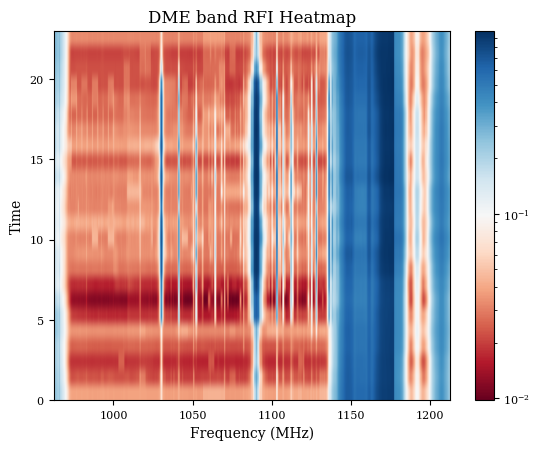

In [54]:
heat_map = data.mean(dim="date")

plt.xlabel("Frequency (MHz)")
plt.ylabel("Time")
im = plt.imshow(heat_map, aspect='auto', 
    extent=[frequency[0], frequency[-1], time[0], time[-1]],
    origin='lower', cmap='RdBu', norm=LogNorm())
cbar = plt.colorbar(im)
plt.title("DME band RFI Heatmap")


### Time Analysis   

#### Daily analysis

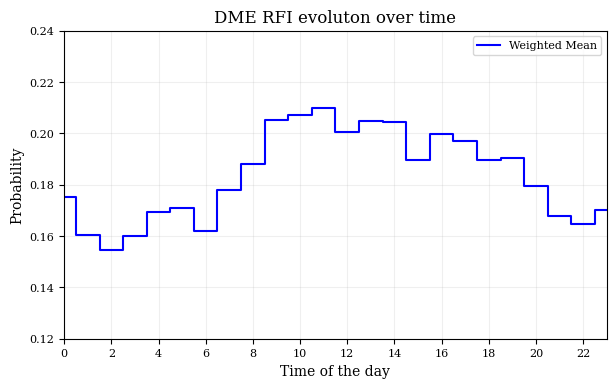

In [77]:
dme_weight_mean = probability(data)[0]
dme_weight_std = probability(data)[1]

plt.figure(figsize=(7,4))
plt.step(time, dme_weight_mean, where="mid", label="Weighted Mean", color="blue")
plt.xticks(np.arange(0,24,2))
plt.xlim(left=0, right=23)
plt.yticks(np.arange(0.12,0.25, 0.02))
plt.grid(alpha=0.2)
plt.xlabel("Time of the day")
plt.ylabel("Probability")
plt.title("DME RFI evoluton over time")
plt.legend()
plt.show()

Total number of observation: 771


Text(0.5, 1.0, 'Observation time coverage')

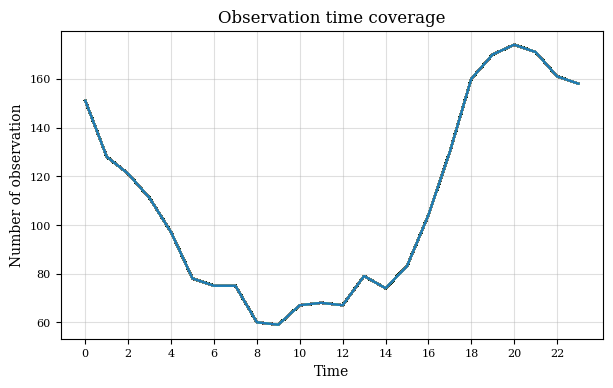

In [63]:
print(f"Total number of observation: {data.shape[0]}")

coverage = data.notnull().sum(dim="date")

plt.figure(figsize=(7,4))
plt.plot(coverage) #marker="o")
plt.xticks(np.arange(0,24,2))
plt.grid(alpha=0.4)
plt.xlabel("Time")
plt.ylabel("Number of observation")
plt.title("Observation time coverage")

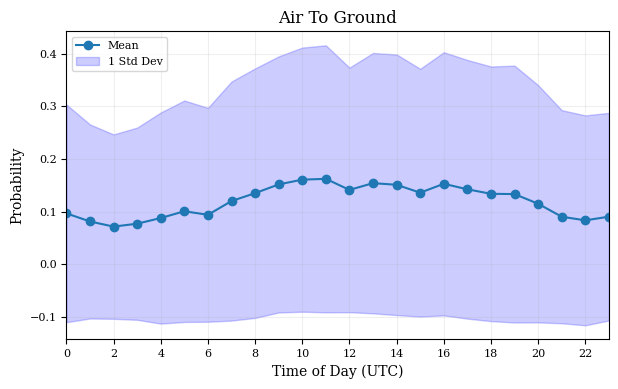

In [79]:
air_gnd = data.sel(frequency=slice(1026*1e6, 1150*1e6))

air_gnd_mean = probability(air_gnd)[0]
air_gnd_std = probability(air_gnd)[1]

figure = plot(air_gnd, air_gnd_mean, air_gnd_std, time, "Air To Ground")



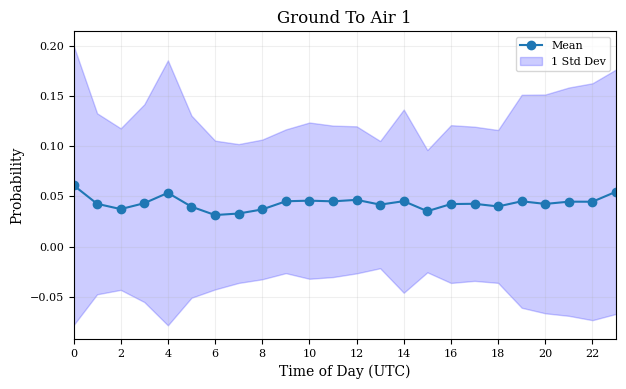

In [80]:
gnd_air1 = data.sel(frequency=slice(932*1e6, 1025*1e6))

gnd_air1_mean = probability(gnd_air1)[0]
gnd_air1_std = probability(gnd_air1)[1]

figure = plot(gnd_air1, gnd_air1_mean, gnd_air1_std, time, "Ground To Air 1")


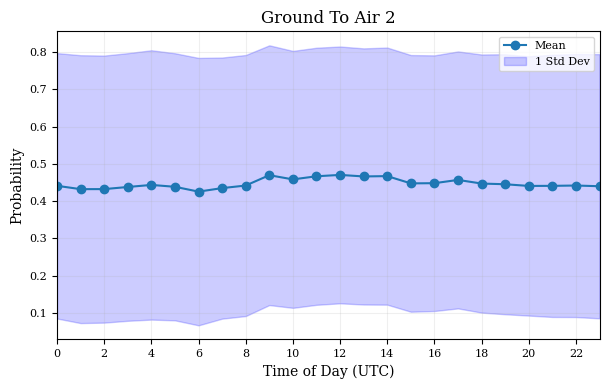

In [82]:
gnd_air2 = data.sel(frequency=slice(1151*1e6, 1213*1e6))

gnd_air2_mean = probability(gnd_air2)[0]
gnd_air2_std = probability(gnd_air2)[1]

figure = plot(gnd_air2, gnd_air2_mean, gnd_air2_std, time, "Ground To Air 2")


#### Yearly Analysis

In [124]:
# 1. Convert your timezone-aware DatetimeArray to a string date format (YYYY)
date_strings = pd.Index(data["date"].values).strftime("%Y")

# 2. Add this as a new coordinate to your dataset
year = data.assign_coords(year_group=("date", date_strings))

# 3. Group by this new coordinate and calculate the mean 
yearly_grouped = year.groupby("year_group")
yearly_grouped

<DataArrayGroupBy, grouped over 1 grouper(s), 6 groups in total:
    'year_group': UniqueGrouper('year_group'), 6/6 groups with labels '2018', '2019', ..., '2023'>

### Frequency Analysis

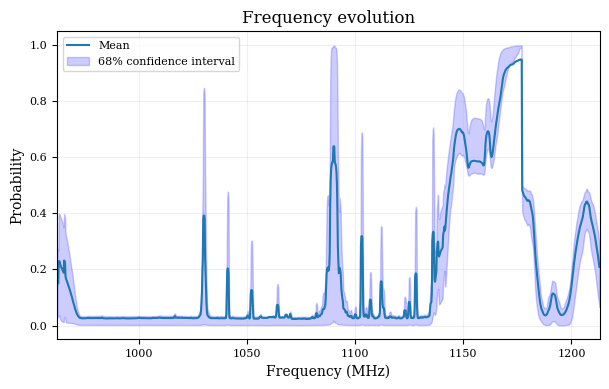

In [ ]:
time_avg = weighted_data.mean(dim=("date", "time"), skipna=True)
std_data = weighted_data.std(dim=("date", "time"), skipna=True)



fig, ax = plt.subplots(figsize=(7,4))
ax.plot(frequency, time_avg, label ='Mean')
ax.set_xticks(np.arange(962,1213,))


# Add the standard deviation band
ax.fill_between(
    frequency, 
    uper, 
    lower, 
    color="blue", 
    alpha=0.2, 
    label="68% confidence interval"
)
ax.set_xlim(left=962, right=1213)
ax.grid(alpha=0.2)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Probability")
ax.set_title("Frequency evolution")
ax.legend()
